# BÀI TẬP: MEDICAL INSURANCE COST
**Nguồn:** kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset



## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')


csv_path = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [2]:
print("So dong:", df.shape[0], "So cot:", df.shape[1])
df.info()

So dong: 1338 So cot: 7
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


## A.2. Missing values & Duplicate data

In [3]:
print(df.isnull().sum())
print("So dong bi trung:", df.duplicated().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
So dong bi trung: 1


## A.3. Invalid values

In [4]:
print("age <= 0:", (df['age']<=0).sum())
print("bmi <= 0:", (df['bmi']<=0).sum())
print("children < 0:", (df['children']<0).sum())
print("charges <= 0:", (df['charges']<=0).sum())
print(df['sex'].unique())
print(df['smoker'].unique())
print(df['region'].unique())

age <= 0: 0
bmi <= 0: 0
children < 0: 0
charges <= 0: 0
<StringArray>
['female', 'male']
Length: 2, dtype: str
<StringArray>
['yes', 'no']
Length: 2, dtype: str
<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


## A.4. Create a new column
Tạo cột `bmi_group`: Normal (<25), Overweight (25-30), Obese (>=30).

In [5]:
def bmi_group(b):
    if b < 25:
        return 'Normal'
    elif b < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_group'] = df['bmi'].apply(bmi_group)
df[['bmi','bmi_group']].head()

,bmi,bmi_group
0,27.900,Overweight
1,33.770,Obese
2,33.000,Obese
3,22.705,Normal
4,28.880,Overweight


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [6]:
for col in ['age','bmi','charges']:
    print(col, "- mean:", df[col].mean(), "median:", df[col].median(), "mode:", df[col].mode()[0])

print("Mode smoker:", df['smoker'].mode()[0])
print("Mode region:", df['region'].mode()[0])

age - mean: 39.20702541106129 median: 39.0 mode: 18
bmi - mean: 30.66339686098655 median: 30.4 mode: 32.3
charges - mean: 13270.422265141257 median: 9382.033 mode: 1639.5631
Mode smoker: no
Mode region: southeast


## Group 2 — Dispersion

In [7]:
for col in ['age','bmi','charges']:
    s = df[col]
    print(col)
    print("Range:", s.max()-s.min())
    print("Std:", s.std())
    print("IQR:", s.quantile(0.75)-s.quantile(0.25))
    print("CV:", s.std()/s.mean())

age
Range: 46
Std: 14.049960379216154
IQR: 24.0
CV: 0.35835313268249896
bmi
Range: 37.17
Std: 6.098186911679014
IQR: 8.3975
CV: 0.19887512591397918
charges
Range: 62648.554110000005
Std: 12110.011236694001
IQR: 11899.625365
CV: 0.9125565859727446


## Group 3 — Location and Shape

bmi - skew: 0.28372857291709386 kurtosis: -0.05502310583700032
charges - skew: 1.5141797118745743 kurtosis: 1.595821363956751


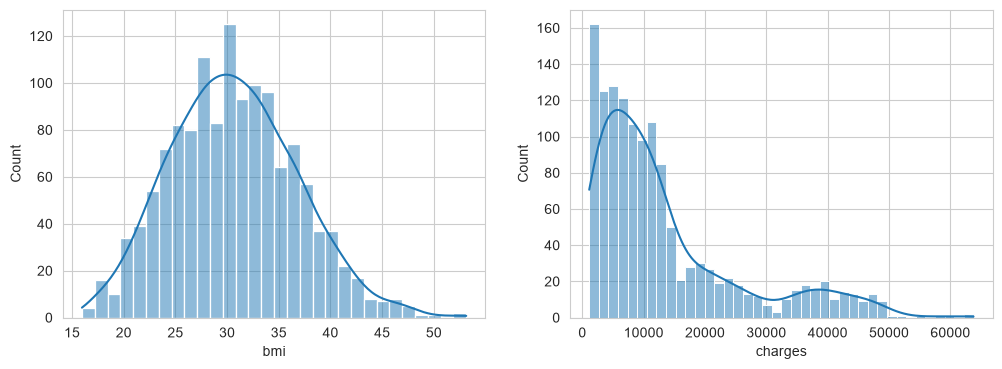

In [8]:
for col in ['bmi','charges']:
    s = df[col]
    print(col, "- skew:", stats.skew(s), "kurtosis:", stats.kurtosis(s))

fig, axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(df['bmi'], bins=30, kde=True, ax=axes[0])
sns.histplot(df['charges'], bins=40, kde=True, ax=axes[1])
plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Người hút thuốc trả chi phí cao hơn bao nhiêu lần so với người không hút, và có đồng đều giữa các vùng không?

In [9]:
smoker_avg = df.groupby('smoker')['charges'].mean()
print(smoker_avg)
print("Chenh lech lan:", smoker_avg['yes']/smoker_avg['no'])

by_region = df.groupby(['region','smoker'])['charges'].mean().unstack()
print(by_region)

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64
Chenh lech lan: 3.800001458298319
smoker              no           yes
region                              
northeast  9165.531672  29673.536473
northwest  8556.463715  30192.003182
southeast  8032.216309  34844.996824
southwest  8019.284513  32269.063494


## Câu hỏi 2: BMI có tương quan với chi phí mạnh hơn ở nhóm hút thuốc hay không hút thuốc?

Smoker yes:
              bmi   charges
bmi      1.000000  0.806481
charges  0.806481  1.000000
Smoker no:
              bmi   charges
bmi      1.000000  0.084037
charges  0.084037  1.000000


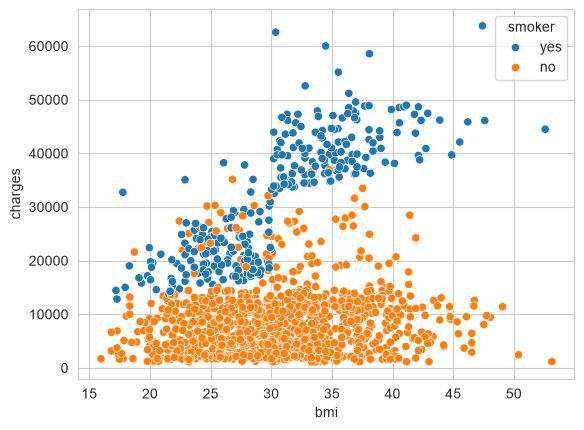

In [10]:
corr_yes = df[df['smoker']=='yes'][['bmi','charges']].corr()
corr_no = df[df['smoker']=='no'][['bmi','charges']].corr()
print("Smoker yes:")
print(corr_yes)
print("Smoker no:")
print(corr_no)

sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker')
plt.show()

## Câu hỏi 3: Vùng nào có chi phí bảo hiểm trung bình cao nhất?

In [11]:
region_avg = df.groupby('region')['charges'].mean().sort_values(ascending=False)
print(region_avg)

region
southeast    14735.411438
northeast    13406.384516
northwest    12417.575374
southwest    12346.937377
Name: charges, dtype: float64


## Câu hỏi 4: Số lượng con cái có làm tăng chi phí bảo hiểm không?

In [12]:
children_avg = df.groupby('children')['charges'].mean()
print(children_avg)
print("Tuong quan children-charges:", df['children'].corr(df['charges']))

children
0    12365.975602
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64
Tuong quan children-charges: 0.06799822684790487


## Câu hỏi 5: Tuổi có tương quan với chi phí bảo hiểm không?

Tuong quan age-charges: 0.29900819333064776


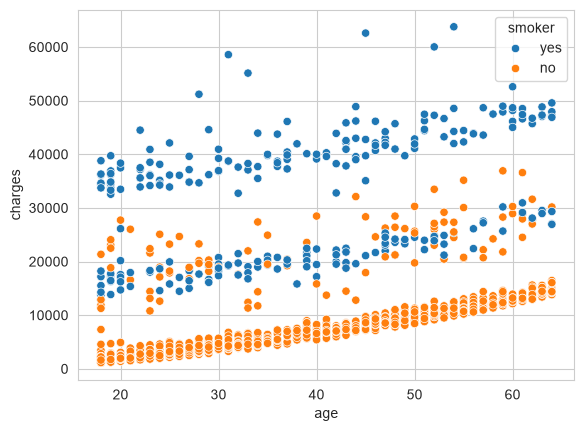

In [13]:
print("Tuong quan age-charges:", df['age'].corr(df['charges']))

sns.scatterplot(data=df, x='age', y='charges', hue='smoker')
plt.show()

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

*Insight:*

Dữ liệu 1338 dòng, khá sạch — chỉ có 1 dòng trùng, không thiếu dữ liệu, không có giá trị vô lý. Yếu tố ảnh hưởng chi phí bảo hiểm nhiều nhất là hút thuốc: người hút thuốc trả phí trung bình cao hơn khoảng 3.8 lần người không hút. Ở nhóm hút thuốc, BMI càng cao thì chi phí càng tăng rõ rệt (tương quan gần 0.8), còn ở nhóm không hút thì BMI gần như không liên quan gì đến chi phí. Vùng Southeast có chi phí trung bình cao nhất trong 4 vùng. Tuổi có tương quan dương nhưng ở mức vừa phải với chi phí, còn số con gần như không ảnh hưởng gì. Nhìn chung, muốn dự đoán chi phí bảo hiểm thì nên quan tâm hút thuốc và BMI trước tiên, còn vùng hay số con không quan trọng bằng.